In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

# 1. Load Dataset (Sesuaikan ekstensi file jika .csv atau .xlsx)
# Jika file kamu adalah Excel:
file_name = 'dataset_resep_format_final (1).xlsx'
df = pd.read_excel(file_name)

# Bersihkan nama kolom dari spasi yang tidak diinginkan
df.columns = df.columns.str.strip()

# Menampilkan 5 data teratas untuk memastikan data masuk
print("--- 5 Data Teratas ---")
print(df.head())

--- 5 Data Teratas ---
                                    nama_menu  \
0  AYAM BAKAR KECAP for breakfast diet GM day   
1   AYAM GORENG BUMBU SEDERHANA pastinya enak   
2                                 AYAM ungkep   
3                Abon Ikan Cakalang ala Bumil   
4                           Abon Ikan Tongkol   

                                               bahan  
0  air, ayam, bawang merah, bawang putih, daun sa...  
1  garam, ayam, bawang merah, bawang putih, jahe,...  
2  air, ayam, bawang putih, bumbu, garam, jahe, k...  
3  ikan cakalang, lemon, cabai rawit, tomat merah...  
4  bawang merah, daun salam, santan, garam, cabai...  


In [2]:
# Fungsi untuk membersihkan teks bahan
def clean_and_split(text):
    if pd.isna(text):
        return []
    # Pisahkan berdasarkan koma, hilangkan spasi di ujung, dan hapus string kosong
    return [b.strip().lower() for b in str(text).split(',') if b.strip()]

# Terapkan fungsi ke kolom 'bahan'
df['bahan_list'] = df['bahan'].apply(clean_and_split)

# Groupby berdasarkan 'nama_menu' untuk menggabungkan bahan dari baris yang sama
df_grouped = df.groupby('nama_menu')['bahan_list'].sum().reset_index()

# Hapus duplikat bahan di dalam resep yang sama (jika ada)
df_grouped['bahan_list'] = df_grouped['bahan_list'].apply(lambda x: list(set(x)))

# Hitung jumlah bahan per resep
df_grouped['jumlah_bahan'] = df_grouped['bahan_list'].apply(len)

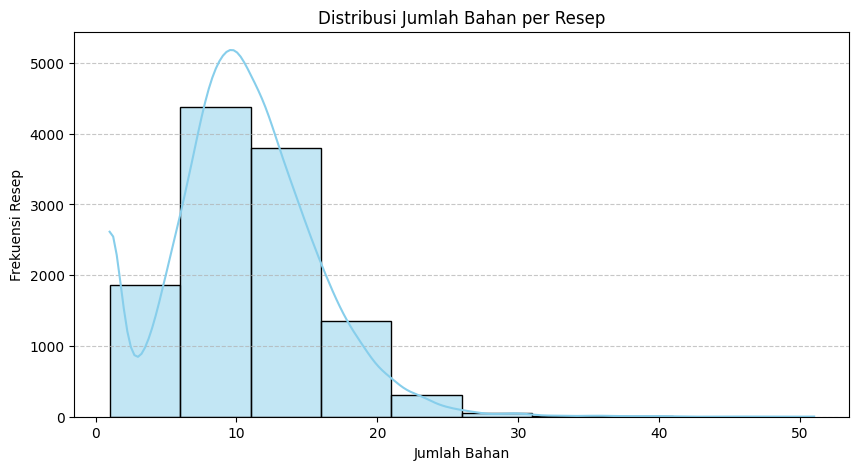

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_grouped['jumlah_bahan'], kde=True, bins=10, color='skyblue')
plt.title('Distribusi Jumlah Bahan per Resep')
plt.xlabel('Jumlah Bahan')
plt.ylabel('Frekuensi Resep')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1412/3127863027.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Bahan', data=df_bahan_freq.head(15), palette='viridis')


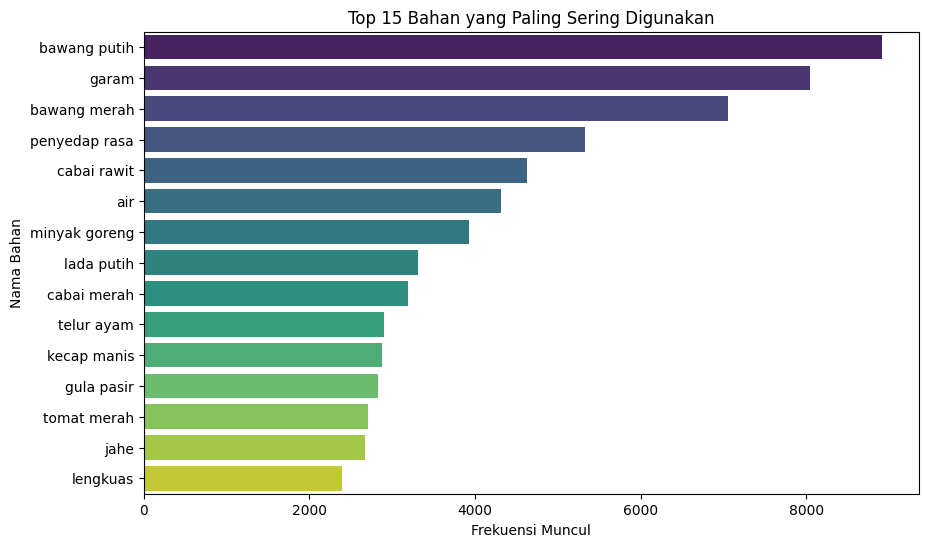


--- 10 Bahan Paling Sering Muncul ---
        Bahan  Frekuensi
 bawang putih       8915
        garam       8044
 bawang merah       7053
penyedap rasa       5322
  cabai rawit       4632
          air       4311
minyak goreng       3926
   lada putih       3312
  cabai merah       3191
   telur ayam       2901


In [4]:
# Menggabungkan semua list bahan menjadi satu list besar
all_ingredients = [bahan for sublist in df_grouped['bahan_list'] for bahan in sublist]

# Hitung frekuensi
bahan_counts = Counter(all_ingredients)
df_bahan_freq = pd.DataFrame(bahan_counts.items(), columns=['Bahan', 'Frekuensi']).sort_values(by='Frekuensi', ascending=False)

# Plot 15 bahan teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Bahan', data=df_bahan_freq.head(15), palette='viridis')
plt.title('Top 15 Bahan yang Paling Sering Digunakan')
plt.xlabel('Frekuensi Muncul')
plt.ylabel('Nama Bahan')
plt.show()

print("\n--- 10 Bahan Paling Sering Muncul ---")
print(df_bahan_freq.head(10).to_string(index=False))

In [14]:
# Menghitung statistik deskriptif deskriptif
mean_bahan = df_grouped['jumlah_bahan'].mean()
median_bahan = df_grouped['jumlah_bahan'].median()
mode_bahan = df_grouped['jumlah_bahan'].mode()[0]
max_bahan = df_grouped['jumlah_bahan'].max()
min_bahan = df_grouped['jumlah_bahan'].min()

print("=== SUMMARY STATISTIK ===")
print(f"Rata-rata Jumlah Bahan : {mean_bahan:.1f} bahan")
print(f"Nilai Tengah (Median)  : {median_bahan} bahan")
print(f"Paling Banyak Muncul   : {mode_bahan} bahan")
print(f"Resep Paling Kompleks  : {max_bahan} bahan")
print(f"Resep Paling Simpel    : {min_bahan} bahan")

=== SUMMARY STATISTIK ===
Rata-rata Jumlah Bahan : 10.4 bahan
Nilai Tengah (Median)  : 10.0 bahan
Paling Banyak Muncul   : 10 bahan
Resep Paling Kompleks  : 51 bahan
Resep Paling Simpel    : 1 bahan


In [13]:
# Hitung kombinasi pasangan bahan per resep
pair_counts = Counter()
for bahan_list in df_grouped['bahan_list']:
    # Sort dulu supaya pasangan (A, B) sama dengan (B, A)
    sorted_bahan = sorted(bahan_list)
    for pair in combinations(sorted_bahan, 2):
        pair_counts[pair] += 1

# Ubah ke DataFrame
df_pairs = pd.DataFrame(pair_counts.items(), columns=['Pasangan Bahan', 'Frekuensi Bersamaan'])
df_pairs = df_pairs.sort_values(by='Frekuensi Bersamaan', ascending=False)

# Tampilkan 10 pasangan teratas
print("\n--- 10 Pasangan Bahan yang Paling Sering Muncul Bersamaan ---")
for idx, row in df_pairs.head(10).iterrows():
    p1, p2 = row['Pasangan Bahan']
    print(f"{p1} & {p2} : muncul bersama di {row['Frekuensi Bersamaan']} resep")


--- 10 Pasangan Bahan yang Paling Sering Muncul Bersamaan ---
bawang putih & garam : muncul bersama di 6996 resep
bawang merah & bawang putih : muncul bersama di 6432 resep
bawang merah & garam : muncul bersama di 5457 resep
bawang putih & penyedap rasa : muncul bersama di 4641 resep
bawang putih & cabai rawit : muncul bersama di 4138 resep
garam & penyedap rasa : muncul bersama di 4110 resep
bawang merah & penyedap rasa : muncul bersama di 3920 resep
bawang merah & cabai rawit : muncul bersama di 3911 resep
air & bawang putih : muncul bersama di 3700 resep
cabai rawit & garam : muncul bersama di 3535 resep
